<a href="https://colab.research.google.com/github/sambencoding/Data-Science-Assignments/blob/main/SamuBenjU5proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import arviz as az
import xarray as xr
import pymc as pm

from scipy.interpolate import PchipInterpolator

#Greenhouse Gas Emmisions in India

I chose to look at greenhouse gas emmisions in india per 100k people and population in the 10s of millions. I chose India because it is a very dense and immensly populated countries. It is also know how polution in the big cities.

Context: Greenhouse gas emissions refers to the release of gases like carbon dioxide, methane, and nitrous oxide into the atmosphere, primarily caused by human activities like burning fossil fuels, industrial processes, agriculture, and deforestation, which trap heat and contribute to global warming and climate change.

In [7]:
url_greenhousegas = 'https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/greenhousegas_pop_10nations.csv'
greenhousegas = pd.read_csv(url_greenhousegas)

In [8]:
greenhousegas

,country,code,year,grnGasEm100K,pop10M
0,Brazil,BRA,1970,12.6098,9.5982
1,Canada,CAN,1970,4.9497,2.1324
2,China,CHN,1970,18.7397,81.8315
3,Germany,DEU,1970,12.8657,7.8169
4,France,FRA,1970,6.1450,5.2035
...,...,...,...,...,...
425,United Kingdom,GBR,2012,5.8578,6.3700
426,India,IND,2012,30.0289,126.3590
427,Japan,JPN,2012,14.7886,12.7561
428,Mexico,MEX,2012,6.6342,12.2071


<Axes: xlabel='pop10M', ylabel='grnGasEm100K'>

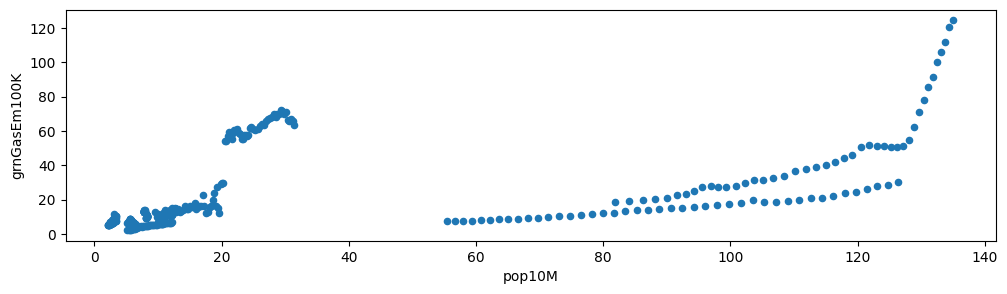

In [9]:
greenhousegas.plot(x="pop10M", y="grnGasEm100K", figsize=(12, 3), kind="scatter")


,country,code,year,grnGasEm100K,pop10M
6,India,IND,1970,7.4650,55.3943
16,India,IND,1971,7.5402,56.6605
26,India,IND,1972,7.6724,57.9801
36,India,IND,1973,7.7357,59.3452
46,India,IND,1974,7.9689,60.7447
56,India,IND,1975,8.2730,62.1704
66,India,IND,1976,8.5260,63.6183
76,India,IND,1977,8.7168,65.0908
86,India,IND,1978,8.7517,66.5936
96,India,IND,1979,9.0545,68.1359


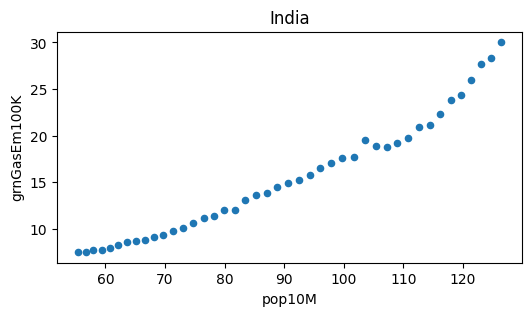

In [14]:
greenhouseIndia = greenhousegas.query('country == "India"')
greenhouseIndia.plot(x="pop10M", y="grnGasEm100K", figsize=(6, 3), kind="scatter", title = "India")
greenhouseIndia

<Axes: ylabel='pop10M'>

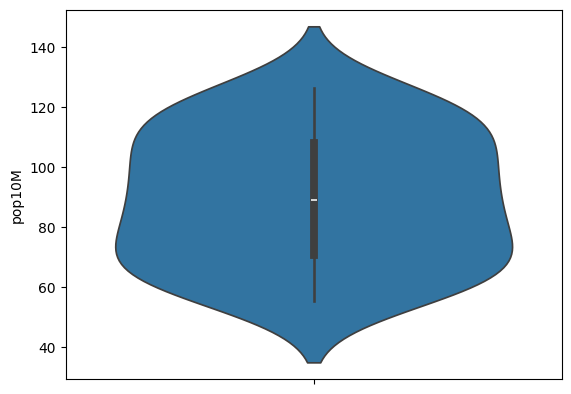

In [15]:
sns.violinplot(greenhouseIndia.pop10M)

I chose a linear model because the scatterplot of the data set is kind of increasing in a steady rate. So I used a linear model with normal priors and likelihood.

In [18]:
with pm.Model() as model_greenhousegas:

    #priors for our mean line
    #the default mean for a normal dist is 0
    α = pm.Normal("α", sigma=10)
    β = pm.Normal("β", sigma=10)

    #mean line
    μ = pm.Deterministic("μ", α + β * greenhouseIndia.pop10M)

    #prior for standard deviation
    σ = pm.HalfNormal("σ", sigma = 10)

    #normal likelihood
    y_pred = pm.Normal("y_pred", mu=μ, sigma=σ, observed=greenhouseIndia.grnGasEm100K)

    idata_greenhousegas = pm.sample()

Output()

Output()

Text(0, 0.5, 'grnGasEm100K')

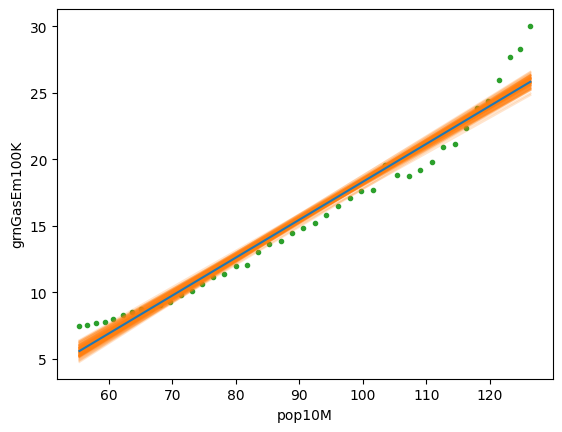

In [19]:
posterior = az.extract(idata_greenhousegas, num_samples=100)

# grabbing x values for graphing.
x_plot = xr.DataArray(
    np.linspace(greenhouseIndia.pop10M.min(), greenhouseIndia.pop10M.max(), 50),
    dims="plot_id"
    )

# this creates the expected line
mean_line = posterior["α"].mean() + posterior["β"].mean() * x_plot

#These are a 50 lines that our model came up with
lines = posterior["α"] + posterior["β"] * x_plot

#set up plot
_, ax = plt.subplots()

#plots 50 other lines our model came up with.
ax.plot(x_plot, lines.T, c="C1", alpha=0.2, label="lines")

#plots the mean line
ax.plot(x_plot, mean_line, c="C0", label="mean line")

#plot the raw data
ax.plot(greenhouseIndia.pop10M, greenhouseIndia.grnGasEm100K, "C2.", zorder=-3)

#label axes and create legend
ax.set_xlabel("pop10M")
ax.set_ylabel("grnGasEm100K")

The posterior is decent but it is missing a lot of the points in the middle and the end. It follows the linear trend in the begining.

Output()

<Axes: xlabel='y_pred'>

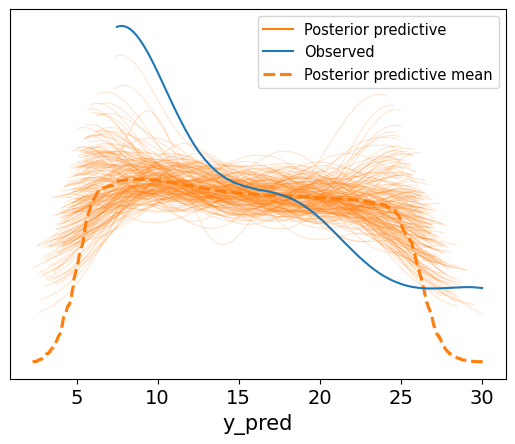

In [20]:
pm.sample_posterior_predictive(
    idata_greenhousegas, model = model_greenhousegas, extend_inferencedata=True
    )

#posterior predictive check
az.plot_ppc(idata_greenhousegas, num_pp_samples=200, colors=["C1", "C0", "C1"])

Text(0, 0.5, 'grnGasEm100K')

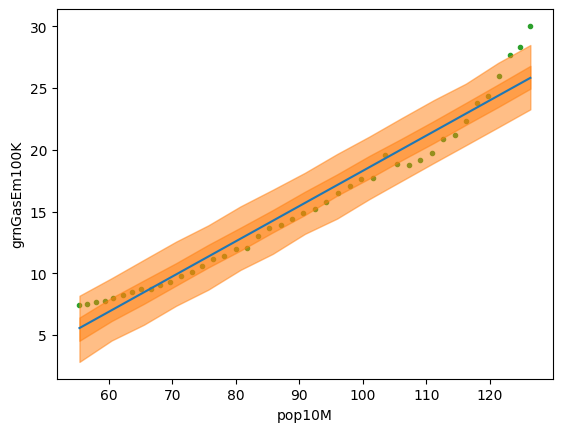

In [23]:
#plots the posterior predictive distribution

greenhouseIndia = greenhouseIndia.reset_index(drop=True)

#grabs the expected line, or line of best fit formula
mean_line = idata_greenhousegas.posterior["μ"].mean(("chain", "draw"))

#creates some x values to run through our line formula
pop10M = np.random.normal(greenhouseIndia.pop10M.values, 0.01)
idx = np.argsort(greenhouseIndia.pop10M.values)
idx = np.argsort(pop10M)
x = np.linspace(pop10M.min(), pop10M.max(), 15)

#grabs the 94% HDI and 50% HDI, and sets them up for graphing.
y_pred_q = idata_greenhousegas.posterior_predictive["y_pred"].quantile(
    [0.03, 0.97, 0.25, 0.75], dim=["chain", "draw"]
)
y_hat_bounds = iter(
    [
        PchipInterpolator(pop10M[idx], y_pred_q[i][idx])(x)
        for i in range(4)
    ]
)

#plots raw data and our line of best fit
_, ax = plt.subplots()
ax.plot(greenhouseIndia.pop10M, greenhouseIndia.grnGasEm100K, "C2.", zorder=-3)
ax.plot(greenhouseIndia.pop10M[idx], mean_line[idx], c="C0")


#graphs the 94% and 50% HDIs
for lb, ub in zip(y_hat_bounds, y_hat_bounds):
    ax.fill_between(x, lb, ub, color="C1", alpha=0.5)

#labels
ax.set_xlabel("pop10M")
ax.set_ylabel("grnGasEm100K")

My posterior predicitive shows that this is a good fit because this follows a very good trend and the model follows the data. This linear model provides a reliable framework for understanding and predicting the behavior of the data within the observed range. There are some big outliers in the end. I think this is the case because India's population has rapidly increased making this the number one country with the biggest population. This leads to increase greenhouse gas emmisions in mig cities. Another reason for the increased emmisions is crop burining to help in removing and fertilizing the fields.